# Start model Structured Product Assignment B1
*Course year 2025-2026*

This notebook provides a starting model to Structured Products Assignment B2. You can fill in blank parts with your own code; also feel free to adjust or replace existing parts. For details on the assignment, please check Canvas. Ensure that the Notebook reads as a cohesive and self-contained report. Take into account factors such as style hints, redundant and inefficient code, proper documentation and consistency of the code.

**Group 1**<br>
**Rick Hezeman (s3450902)**<br>
**Roy Mulder (s2587572)**<br>
**Jeroen Pouwels (s2389878)**<br>
**Ruben Stevenaar (s2633582)**<br>
**Justus Straus (s2636662)**<br>

<p align="center">
<img src="https://blog.billyoh.com/wp-content/uploads/2021/08/cool-hedge-ideas-2-outdoor-hedge-maze-1.jpg" width="100px" alt="Hedge">
</p>

Useful links:<br>
[Introduction to Jupyter Notebook](https://www.dataquest.io/blog/jupyter-notebook-tutorial/)<br>
[UT JupyterLab wiki](https://jupyter.wiki.utwente.nl/)<br>
[Markdown language](https://learn.microsoft.com/en-us/azure/devops/project/wiki/markdown-guidance?view=azure-devops)<br>

In [7]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from math import exp, log
from scipy.stats import norm

In [37]:
np.random.seed(34)

In [38]:
def plot_results(t, array_t, array_delta, array_price, array_strike, array_position, array_nr_stocks):
    """Plot (i) portfolio delta, (ii) stock price, (iii) #stocks traded and
       (iv) stock position over time"""

    # Convert arrays
    array_t_plot = array_t[0:t]
    array_delta_plot = array_delta[0:t]
    array_price_plot = array_price[0:t]
    array_strike_plot = array_strike[0:t]
    array_position_plot = array_position[0:t]
    array_nr_stocks_plot = array_nr_stocks[0:t]

    fig, axes = plt.subplots(nrows=2, ncols=2)
    fig.tight_layout(h_pad=1)

    # Define plots
    delta_plot, = axes[0, 0].plot(array_t_plot, array_delta_plot)
    price_plot, = axes[0, 1].plot(array_t_plot, array_price_plot)
    strike_plot, = axes[0, 1].plot(array_t_plot, array_strike_plot)
    stocks_plot, = axes[1, 0].plot(array_t_plot, array_nr_stocks_plot)
    position_plot, = axes[1, 1].plot(array_t_plot, array_position_plot)

    # Define axis labels
    axes[0, 0].set(xlabel="Day", ylabel="Delta")
    axes[0, 1].set(xlabel="Day", ylabel="Stock price")
    axes[1, 0].set(xlabel="Day", ylabel="# stocks traded")
    axes[1, 1].set(xlabel="Day", ylabel="Long position")

    # Set axis ranges
    axes[0, 0].set_ylim([-1, 1])
    axes[1, 1].set_ylim([-0.1, 1.1])
    axes[1, 0].set_ylim([-0.1, 10])  # If needed, adjust this range

    # Define legends
    axes[0, 1].legend([price_plot, strike_plot], ["Stock", "Strike"])

    plt.show()

In [39]:
"""Dynamically delta hedge portfolio of short call options"""
S = 100  # Initial stock price
v = 0.01  # Volatility (0.01=1%)
r = 0.01  # Risk-free rate (0.01=1%)
K = 100  # Strike price, ATM option
T = 1  # Expiration date, in years
N = 252 # Number of trading days in a year         
dt = T / N # Time increment per trading day
sigma = 0.20 # Annualized volatility (20%)

In [40]:
def bs_price_call(S, K, r, sigma, tau):
    "BS price of a European call option"
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)


def bs_delta_call(S, K, r, sigma, tau):
    "BS delta of a European call option"
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return float(norm.cdf(d1))

z = np.random.normal(0.0, 1.0, size=N)

def GBM(S: float, r: float, sigma: float, dt: float, z: np.ndarray) -> np.ndarray:
    "Simulate Geometric Brownian Motion (GBM) stock price paths."
    price_change = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)

    Stock_price = np.zeros(N+1)
    Stock_price[0] = S
    for t in range(1, N + 1):
        Stock_price[t] = Stock_price[t - 1] * price_change[t - 1]
    # Return the simulated stock price path
    print(S)
    return Stock_price
    

time = np.linspace(0.0, T, N + 1)

In [ ]:
# Initialize output variables and arrays
array_t = np.zeros(N + 1)
array_delta = np.zeros(N + 1)
array_price = np.zeros(N+1)
array_strike = np.zeros(N+1)
array_position = np.zeros(N+1)
array_nr_stocks = np.zeros(N+1)
array_cost_balance = np.zeros(N+1)

# Compute initial properties of call options
# Hint: write a function that returns price and delta of the option
option0 = bs_price_call(S, K, r, sigma, T)
delta_prev = bs_delta_call(S, K, r, sigma, T)


# Hint: use Black-Scholes formula for the option price
array_price = GBM(S, r, sigma, dt, z)



position_long = 0  # Initial long stock position
portfolio_value = 0  

# Compute initial hedge, initialization
adjust_hedge = 1  # Update hedge
position_long += delta_prev  # Update long stock position based on stocks bought/sold
long_value = position_long * array_price[0]  # Value of long stock position
portfolio_value += long_value -option0    # Update value based on stocks bought/sold
portfolio_delta = position_long- delta_prev  # Update portfolio delta
initial_cost = long_value - option0  # Initial cost of the portfolio


# Hint: portfolio delta should be 0 after this initial hedge

# Print initial output
print('\n======= Initial =======')
print('Stock price %.2f' % S)
print('Option value %.2f' % option0) 
print('Long position %.2f' % position_long)
print('Total transactions %.2f' % abs(adjust_hedge))  # Nr. of transactions
print('long_value: %.2f' % long_value)
print('Portfolio value %.2f' % portfolio_value)
print('Delta %.2f' % portfolio_delta)
print('Cost balance %.2f' % initial_cost)

# Store data at t=0
array_t[0] = 0
array_delta[0] = portfolio_delta
array_price[0] = S  # Store stock prices
array_strike[0] = K
array_position[0] = position_long  # Store stock positions
array_nr_stocks[0] = abs(adjust_hedge)  # Store nr. of transactions
array_cost_balance[0] = initial_cost  # Store cost balance

# Simulate portfolio updates for time horizon
for t in range(1, N+1):
    array_t[t] = t

    array_delta[t] = portfolio_delta
    asset_price = array_price[t]  # Update stock price
    position_long = array_position[t-1]  # Update long position
    bs_delta_call(asset_price, K, r, sigma, T - (array_t[t]/252))



    # Update call properties
    # Compute new delta and price of the option 

    # Compute new portfolio delta

    # Determine number of stocks to buy or sell
    # Hint: aim to rebalance the portfolio to delta=0 again

    # Update long position
    # Hint: check if delta is 0 after the update

    # Store data
    array_t[t] = t
    array_delta[t] = 0
    array_price[t] = asset_price
    array_strike[t] = K
    array_position[t] = position_long
    array_nr_stocks[t] = long_value
    # code interest payments


    # Update stock price

    # If maturity, close all option and stock positions here
        # Close option position
        # Hint: at maturity, the option is worth max(S-K, 0)

        # Close stock position
        #    Determine final portfolio value (hint: should be close to 0)



    # Print console output
    print('\n=======', t, '=======')
    print('Stock price %.2f' % asset_price)
    print('Option value %.2f')
    print('Hedge adjustment %.2f' % adjust_hedge)
    print('Long position %.2f' % position_long)
    print('Total transactions %.2f' % array_nr_stocks[t])
    print('Portfolio value %.2f' % portfolio_value)
    print('Delta %.2f' % portfolio_delta)
    print('Cost balance %.2f' % array_cost_balance[t])

100

======= Initial =======
Stock price 100.00
Option value 8.43
Long position 0.56
Total transactions 1.00
long_value: 55.96
Portfolio value 47.53
Delta 0.00
Cost balance 47.53

======= 1 =======
Stock price 100.30
Option value %.2f
Hedge adjustment 1.00
Long position 0.56
Total transactions 55.96
Portfolio value 47.53
Delta 0.00
Cost balance 0.00

======= 2 =======
Stock price 99.36
Option value %.2f
Hedge adjustment 1.00
Long position 0.56
Total transactions 55.96
Portfolio value 47.53
Delta 0.00
Cost balance 0.00

======= 3 =======
Stock price 97.42
Option value %.2f
Hedge adjustment 1.00
Long position 0.56
Total transactions 55.96
Portfolio value 47.53
Delta 0.00
Cost balance 0.00

======= 4 =======
Stock price 96.85
Option value %.2f
Hedge adjustment 1.00
Long position 0.56
Total transactions 55.96
Portfolio value 47.53
Delta 0.00
Cost balance 0.00

======= 5 =======
Stock price 96.42
Option value %.2f
Hedge adjustment 1.00
Long position 0.56
Total transactions 55.96
Portfolio v

C:\Users\justu\AppData\Local\Temp\ipykernel_16188\1518723650.py:10: RuntimeWarning: divide by zero encountered in scalar divide
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))


In [60]:
long_value

np.float64(55.96176923702425)

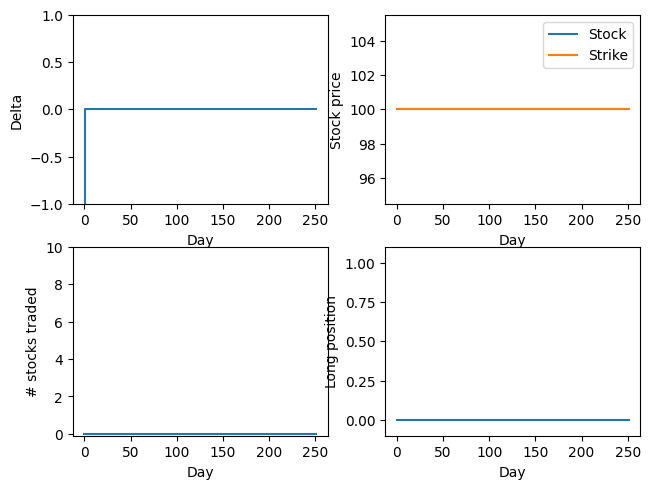

In [34]:
    # Update price plot
    # Hint: not necessary at every time step
plot_results(t, array_t, array_delta, array_price, array_strike, array_position, array_nr_stocks)